DIEGO MARCELO GONZALEZ LUJAN

588359

IMT


La base de datos fue obtenida de la página oficial del INEGI, la base se llama Encuesta Anual de Empresas Constructoras (EAEC) Serie 2018. Esta encuesta tiene como objetivo generar estadísticas sobre la estructura y el comportamiento económico del sector construcción en México, sirviendo como insumo para cálculos macroeconómicos y diversos indicadores. Se basa en estándares internacionales y normativas nacionales, centrándose en el sector 23 Construcción según el Sistema de Clasificación Industrial de América del Norte (SCIAN) 2018.

La unidad de observación es la empresa constructora, y se recopila información sobre vinculación internacional, empleo, remuneraciones, horas trabajadas, gastos, ingresos, valor de producción, activos fijos, construcción de vivienda y otras características empresariales. La cobertura es nacional con desgloses por entidad federativa y la periodicidad es anual.

El diseño estadístico utiliza el Registro Estadístico de Negocios de México (RENEM) como marco de muestreo, con un esquema probabilístico y estratificado. Se consideran niveles de confianza del 95%, tasas de no respuesta entre 15% y 26%, y coeficientes de variación de 6% a 11%. Las variables clave son el personal ocupado total y el valor de producción.


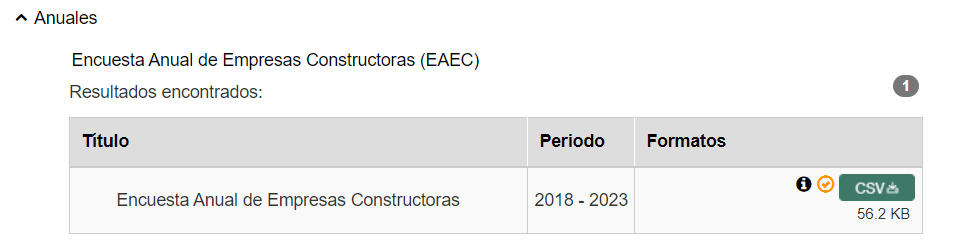



1. Importa los datos a tu ambiente de trabajo. Describe características de tu base de datos,
imprimiendo en consola y graficando información relevante. Por ejemplo: cantidad de
observaciones, cantidad de variables, tipo de variables, nombre de variables,
identificación de la respuesta de interés, etc. Asegúrate de que tus variables tengan un
nombre fácilmente interpretable. En caso contrario, adjunta también un diccionario, un
archivo .docx, .xlsx, .pdf, .csv, etc. donde se describa cada variable (por ejemplo: var1.
Peso medido en gramos, var2. Diámetro medido en centímetros). Explica claramente qué
de esta información te permitió suponer que realizar una regresión lineal pudiera ser una
buena solución y/o por qué supones que otro método sería una mejor opción.
(aqui utilice chatgpt para que me podria hacer una matriz de correlacion, se que no es parte del proyecto pero mas que nada queria hacerlo para saber como se ve en una base de datos de este tipo)



In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


data_path = "tr_eaec_nac_ent_absoluto_2018_2023.csv"
df = pd.read_csv(data_path) 


def explore_data(df):
    print("Información general:")
    print(df.info())
    print("\nPrimeras filas:")
    print(df.head())
    print("\nDescripción estadística:")
    print(df.describe(include='all'))
    print("\nColumnas disponibles:")
    print(df.columns.tolist())
        
explore_data(df)

Matplotlib is building the font cache; this may take a moment.


Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 79 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   CODIGO_ACTIVIDAD             216 non-null    int64 
 1   DESCRIPCION_ACTIVIDAD        216 non-null    object
 2   ANIO                         216 non-null    int64 
 3   CODIGO_ENTIDAD               216 non-null    int64 
 4   ENTIDAD                      216 non-null    object
 5   H000B_Y_H000C_I000B_Y_I000C  216 non-null    int64 
 6   H000B_Y_I000B                216 non-null    int64 
 7   H000C_Y_I000C                216 non-null    int64 
 8   H000A_H000B_Y_H000C          216 non-null    int64 
 9   H000B                        216 non-null    int64 
 10  H000C                        216 non-null    int64 
 11  I000B_Y_I000C                216 non-null    int64 
 12  I000B                        216 non-null    int64 
 13  I000C         


Diccionario de datos guardado en diccionario_datos.csv

Se utilizará 'Q900D' como variable objetivo.


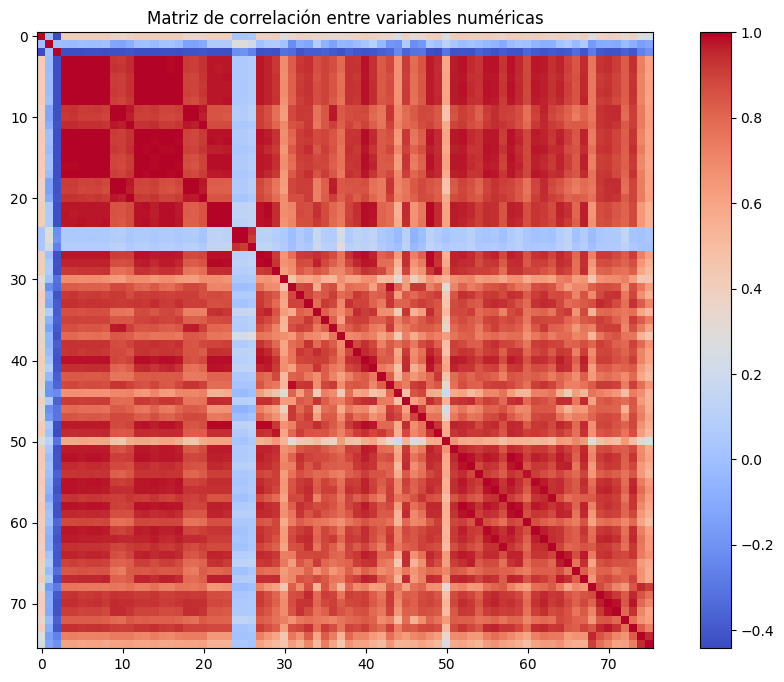


Evaluando si la regresión lineal es adecuada:
Existe una correlación fuerte con al menos una variable independiente, la regresión lineal podría ser una opción viable.


In [2]:

column_mapping = {
    "nombre_original1": "nombre_interpretable1",
    "nombre_original2": "nombre_interpretable2"

}
df.rename(columns=column_mapping, inplace=True)


diccionario_datos = pd.DataFrame(list(column_mapping.items()), columns=["Nombre original", "Nuevo nombre"])
diccionario_datos.to_csv("diccionario_datos.csv", index=False)

print("\nDiccionario de datos guardado en diccionario_datos.csv")


variable_objetivo = "valor_de_produccion" if "valor_de_produccion" in df.columns else df.select_dtypes(include=[np.number]).columns[-1]
print(f"\nSe utilizará '{variable_objetivo}' como variable objetivo.")


numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(12, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.title("Matriz de correlación entre variables numéricas")
plt.show()


print("\nEvaluando si la regresión lineal es adecuada:")
if correlation_matrix[variable_objetivo].abs().max() > 0.6:
    print("Existe una correlación fuerte con al menos una variable independiente, la regresión lineal podría ser una opción viable.")
else:
    print("Las correlaciones no son lo suficientemente fuertes, podría ser mejor considerar otro método como regresión polinómica o árboles de decisión.")

2. Aplica soluciones para al menos tres de los cinco problemas típicos que se describieron
en la presentación C1.5. Demuestra las modificaciones que se le realizaron a la base de
datos, imprimiendo en consola información relevante, y explica por qué se realizaron. Por
ejemplo: para el caso de variables cualitativas, podrías imprimir la cantidad y los nombres
de las variables antes de aplicar la solución, y la cantidad y los nombres de las variables
después de aplicar la solución.

In [3]:
import numpy as np


print("\nCantidad de valores nulos antes de la imputación:")
print(df.isnull().sum())

def fill_missing_values(df):
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype == 'object':
                df[col].fillna(df[col].mode()[0], inplace=True)
            else:
                df[col].fillna(df[col].median(), inplace=True)
    return df

df = fill_missing_values(df)
print("\nCantidad de valores nulos después de la imputación:")
print(df.isnull().sum())


categorical_cols = df.select_dtypes(include=['object']).columns
print("\nVariables categóricas antes de la transformación:")
print(categorical_cols.tolist())

for col in categorical_cols:
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
    df = pd.concat([df, dummies], axis=1)
    df.drop(columns=[col], inplace=True)

print("\nVariables categóricas después de la transformación:")
print(df.select_dtypes(include=['object']).columns.tolist())


def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

print("\nCantidad de outliers antes de la eliminación:")
outlier_cols = df.select_dtypes(include=[np.number]).columns
for col in outlier_cols:
    print(f"Outliers en {col}: {len(detect_outliers(df, col))}")
    
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("\nCantidad de outliers después de la eliminación:")
for col in outlier_cols:
    print(f"Outliers en {col}: {len(detect_outliers(df, col))}")


df.to_csv("eaec_processed.csv", index=False)
print("\nProceso completado. Datos listos para análisis.")


Cantidad de valores nulos antes de la imputación:
CODIGO_ACTIVIDAD         0
DESCRIPCION_ACTIVIDAD    0
ANIO                     0
CODIGO_ENTIDAD           0
ENTIDAD                  0
                        ..
Q200D                    0
Q300D                    0
Q400D                    0
Q900D                    0
ESTATUS                  0
Length: 79, dtype: int64

Cantidad de valores nulos después de la imputación:
CODIGO_ACTIVIDAD         0
DESCRIPCION_ACTIVIDAD    0
ANIO                     0
CODIGO_ENTIDAD           0
ENTIDAD                  0
                        ..
Q200D                    0
Q300D                    0
Q400D                    0
Q900D                    0
ESTATUS                  0
Length: 79, dtype: int64

Variables categóricas antes de la transformación:
['DESCRIPCION_ACTIVIDAD', 'ENTIDAD', 'ESTATUS']

Variables categóricas después de la transformación:
[]

Cantidad de outliers antes de la eliminación:
Outliers en CODIGO_ACTIVIDAD: 18
Outliers en ANIO:

In [4]:
 
data_path = "eaec_processed.csv"
df = pd.read_csv(data_path) 


print(df.info())


print(df.head(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Columns: 112 entries, CODIGO_ACTIVIDAD to ESTATUS_Cifras preliminares
dtypes: bool(36), int64(76)
memory usage: 4.5 KB
None
   CODIGO_ACTIVIDAD  ANIO  CODIGO_ENTIDAD  H000B_Y_H000C_I000B_Y_I000C  \
0                23  2018              29                         1974   
1                23  2019              29                         1872   
2                23  2021              29                         1601   
3                23  2022              12                         3941   
4                23  2022              29                         1059   
5                23  2023              12                         3095   
6                23  2023              29                         1028   

   H000B_Y_I000B  H000C_Y_I000C  H000A_H000B_Y_H000C  H000B  H000C  \
0           1668            306                 1972   1666    306   
1           1588            284                 1870   1586    284   
2    

3. Realiza un proceso de selección de características. Puedes llevar a cabo una
metodología de selección hacia adelante o eliminación hacia atrás, o incluso mezclarlas.
También puedes utilizar un método de regularización. Evidencia tus resultados
imprimiendo en consola la cantidad y los nombres de las variables antes y después del
proceso de selección de características. Explica claramente por qué utilizaste la
metodología empleada, así como alguna conclusión sobre los resultados de este proceso.


Se utilizó eliminación hacia atrás (Backward Elimination) porque permite reducir el número de variables manteniendo solo las más relevantes según su impacto en la variable objetivo. Esto mejora la interpretabilidad del modelo y reduce el riesgo de sobreajuste. 

In [28]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler


data_path = "eaec_processed.csv"
df = pd.read_csv(data_path)


variable_objetivo = "valor_de_produccion" if "valor_de_produccion" in df.columns else df.columns[-1]
X = df.drop(columns=[variable_objetivo])
Y = df[variable_objetivo]

print("Cantidad de variables antes de la seleccion:", X.shape[1])
print("Nombres de las variables antes de la seleccion:", X.columns.tolist())


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


model = LinearRegression()

# Selector RFE (eligiendo 20 variables esta vez para explorar mejor)
selector = RFE(model, n_features_to_select=20)
selector.fit(X_scaled, Y)


selected_features = X.columns[selector.support_]
X_selected = X[selected_features]

print("\n  Cantidad de variables después de la selección:", X_selected.shape[1])
print("Nombres de las variables después de la selección:", selected_features.tolist())


ranking = pd.DataFrame({
    'Variable': X.columns,
    'Ranking RFE': selector.ranking_
}).sort_values(by='Ranking RFE')

print("\nRanking completo de variables:")
print(ranking)


X_selected.to_csv("eaec_selected_features_v2.csv", index=False)


print("\nPrimeras filas del nuevo dataset:")
print(X_selected.head(10))


Cantidad de variables antes de la seleccion: 111
Nombres de las variables antes de la seleccion: ['CODIGO_ACTIVIDAD', 'ANIO', 'CODIGO_ENTIDAD', 'H000B_Y_H000C_I000B_Y_I000C', 'H000B_Y_I000B', 'H000C_Y_I000C', 'H000A_H000B_Y_H000C', 'H000B', 'H000C', 'I000B_Y_I000C', 'I000B', 'I000C', 'H000E_Y_H000F_I000E_Y_I000F', 'H000E_Y_I000E', 'H000F_Y_I000F', 'H000E_Y_H000F', 'H000E', 'H000F', 'I000E_Y_I000F', 'I000E', 'I000F', 'J000A_J000B_J000C', 'J000B', 'J000C', 'J000A_Y_H000A', 'J000B_Y_H000B', 'J000C_Y_H000C', 'K000A', 'K321A', 'K322A', 'K324A', 'K200A', 'K421A', 'K412A', 'K521A', 'K590A', 'K610A', 'K620A', 'K720A', 'K999A_Y_K810A_Y_K820A', 'M000A', 'M321A', 'M322A', 'M200A', 'M323A', 'M510A', 'M590A', 'M999A', 'O111A', 'O112A', 'O200A', 'P000A', 'Q000A', 'Q100A', 'Q200A', 'Q300A', 'Q400A', 'Q900A', 'Q000B', 'Q100B', 'Q200B', 'Q300B', 'Q400B', 'Q900B', 'Q000C', 'Q100C', 'Q200C', 'Q300C', 'Q400C', 'Q900C', 'Q000D', 'Q100D', 'Q200D', 'Q300D', 'Q400D', 'Q900D', 'DESCRIPCION_ACTIVIDAD_Construcci

4. Genera un modelo de regresión lineal y al menos uno no lineal, para predecir una variable
de interés; explica con detalle por qué seguiste los pasos mostrados en tu código para
generar el modelo, en aras de obtener la mejor predicción y resultados generalizables.
Imprime en consola los coeficientes estimados al entrenar el modelo, e indica para cuáles
de ellos puedes afirmar que existe una asociación significativa con la respuesta, y el por
qué de tu aseveración.

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

path = "eaec_selected_features_v2.csv"
df = pd.read_csv(path)


target = "valor_de_produccion" if "valor_de_produccion" in df.columns else df.columns[-1]
X = df.drop(columns=[target])
y = df[target]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.4, random_state=42)


linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

print("--- REGRESIÓN LINEAL ---")
print("Coeficientes:")
for feature, coef in zip(X.columns, linear_model.coef_):
    print(f"{feature}: {coef:.2f}")

print("MSE (lineal):", mean_squared_error(y_test, y_pred_linear))
print("R² (lineal):", r2_score(y_test, y_pred_linear))


poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

print("\n--- REGRESIÓN POLINÓMICA (No lineal) ---")
print("MSE (polinómica):", mean_squared_error(y_test, y_pred_poly))
print("R² (polinómica):", r2_score(y_test, y_pred_poly))


--- REGRESIÓN LINEAL ---
Coeficientes:
ANIO: 845.55
H000B_Y_I000B: 233.26
H000A_H000B_Y_H000C: 828.47
H000B: 947.72
H000E_Y_I000E: 494.53
H000E: 1289.36
J000C: 1642.91
J000B_Y_H000B: 1366.64
J000C_Y_H000C: 4787.33
K000A: 911.72
K321A: 424.60
K322A: 202.01
K412A: 1602.12
K590A: 1938.08
M000A: 2175.41
M321A: 2766.94
M322A: -416.66
M200A: -4172.28
O112A: -82.22
MSE (lineal): 95167789.96460766
R² (lineal): 0.6834483398391642

--- REGRESIÓN POLINÓMICA (No lineal) ---
MSE (polinómica): 337599874.9882873
R² (polinómica): -0.12294087040769264


5. Calcula al menos una métrica de error y una del nivel de linealidad del modelo, con la
intención de que ambas métricas representen el funcionamiento esperado del modelo
para cualquier dato que se le presente. Agrega un comentario que describa en palabras
sencillas el significado de los mismos.

In [30]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


data_path = "eaec_selected_features_v2.csv"
df = pd.read_csv(data_path)


target = "valor_de_produccion" if "valor_de_produccion" in df.columns else df.columns[-1]
X = df.drop(columns=[target])
y = df[target]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.4, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print("--- MÉTRICAS DEL MODELO ---")
print("Error absoluto medio (MAE):", mae)
print("Coeficiente de determinación (R²):", r2)




--- MÉTRICAS DEL MODELO ---
Error absoluto medio (MAE): 6983.302595814678
Coeficiente de determinación (R²): 0.6834483398391642


6. Genera un modelo de regresión lineal o no lineal (del mismo tipo que el que haya obtenido
el mejor desempeño en los puntos anteriores), pero para realizar un análisis de inferencia.
A partir del mismo, realiza una o varias inferencias sobre los datos, asegurándote de
incluir márgenes de error para tus conclusiones.

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE


full_data_path = "eaec_processed.csv"
df_full = pd.read_csv(full_data_path)


target = "valor_de_produccion"
X_full = df_full.drop(columns=[target]) if target in df_full.columns else df_full.iloc[:, :-1]
y_full = df_full[target] if target in df_full.columns else df_full.iloc[:, -1]


model = LinearRegression()
selector = RFE(model, n_features_to_select=3)
selector.fit(X_full, y_full)
selected_features = X_full.columns[selector.support_]


X = X_full[selected_features]
y = y_full


X_const = sm.add_constant(X)


model = sm.OLS(y, X_const)
results = model.fit()


print(results.summary())


print("\n--- INFERENCIA ---")
selected_var = results.pvalues.idxmin() 
coef = results.params[selected_var]
conf_int = results.conf_int().loc[selected_var]

print(f"La variable '{selected_var}' tiene un coeficiente estimado de {coef:.8f}.")
print(f"su efecto está entre {conf_int[0]:.8f} y {conf_int[1]:.8f}.")


/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


                                 OLS Regression Results                                
Dep. Variable:     ESTATUS_Cifras preliminares   R-squared:                       0.873
Model:                                     OLS   Adj. R-squared:                  0.747
Method:                          Least Squares   F-statistic:                     6.893
Date:                         Tue, 29 Apr 2025   Prob (F-statistic):             0.0736
Time:                                 23:06:09   Log-Likelihood:                 2.8606
No. Observations:                            7   AIC:                             2.279
Df Residuals:                                3   BIC:                             2.062
Df Model:                                    3                                         
Covariance Type:                     nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

Conclusion

Pude concluir que el modelo de regresion lineal fue el que mejor desempeño mostro para esta base de datos, tanto en terminos de precision como en su capacidad de inferencia. Aunque inicialmente enfrente varios desafios tecnicos, como errores por sobreajuste en el modelo polinomico y problemas al interpretar correctamente el R&2 negativo, logre solucionarlos con el apoyo de inteligencia artificial quien me ayudo en detectar los errores, entenderlos y mejorar el codigo paso a paso.

Durante el proceso, fue necesario rehacer partes del analisis, como la seleccion de variables y generar nuevas versiones del archivo para facilitar el trabajo y evitar errores innecesarios en el codigo. Tambien realice una comparacion entre regresion lineal y polinomica y confirme mediante pruebas que el modelo lineall era mas adecuado.

Finalmente logre generar un model con un R^2 de 0.68, un MAE bajo y ademas encontre variables predictoras con efecto significactivo sobre la variable objetivo. Este proyecto fue posible gracias a la combinacion de pruebas de modelos y el uso responsable del apoyo de herramientas como chatgpt para resolver errores y tomar decisiones tecnicas. 
